Для того, чтобы парсить из VK, тебе необходимо сперва получить API ключ. API ключ выдается для использования каким-либо приложением. Это может быть как внутреннее приложение ВК, так и внешнее на любом сайте.

Для того, чтобы получить ключ, тебе необходимо зайти в аккаунт для разработчика и создать свое приложение.

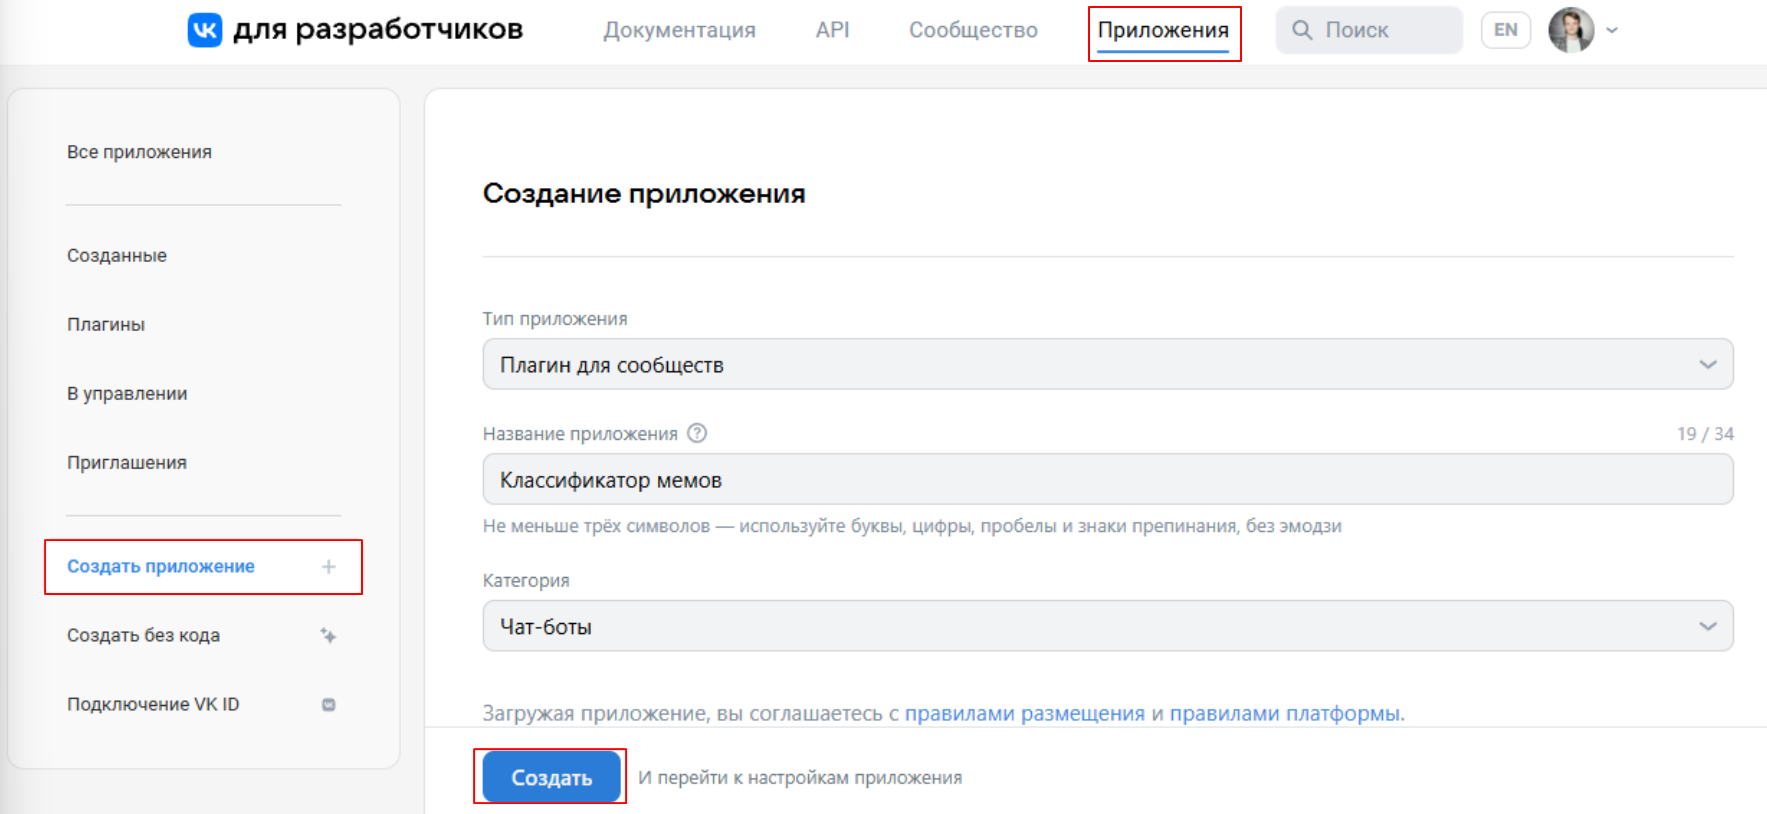

Далее в вкладке разработка вам понадобится сервистный ключ. Именно с его помощью вы будете обращаться к API вк.

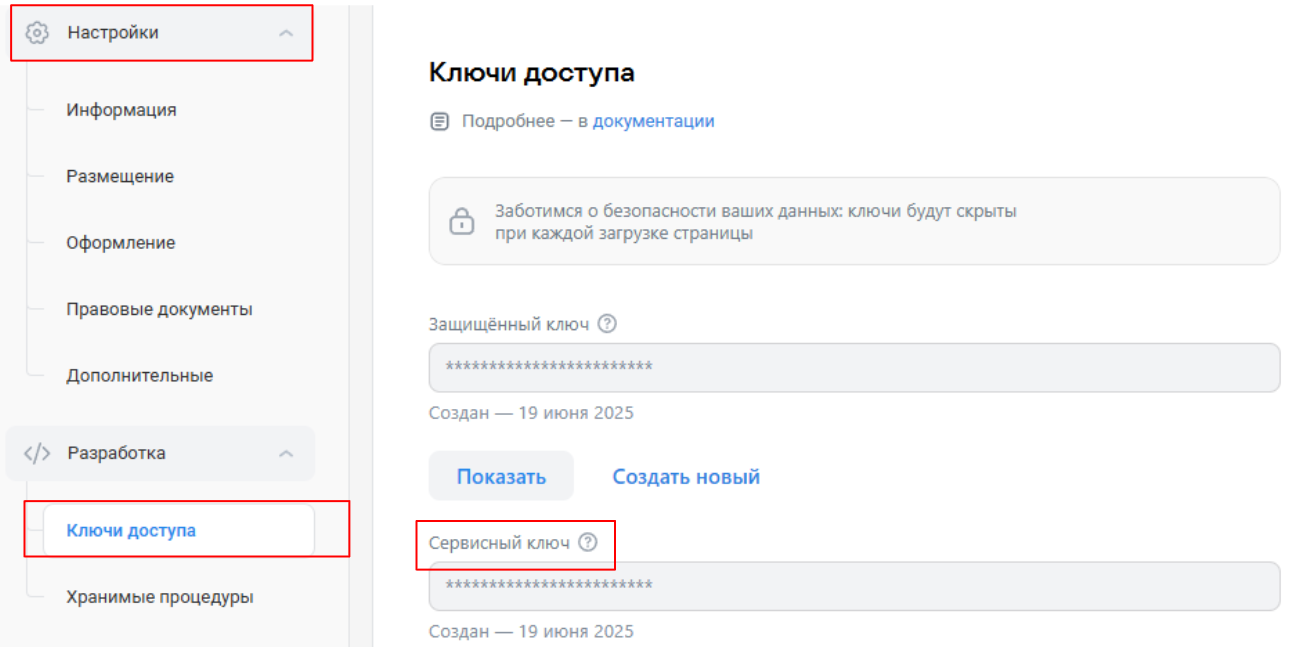

In [3]:
# Также тебе понадобится библиотека vk_api
!pip install vk_api

In [4]:
import json # В json файл сохрани свой ключ
import vk_api

from tqdm import tqdm

Далее представлен класс для парсинга постов из сообществ ВКонтакте. Он получает всю информацию из поста и складывает в словарь. То есть все будет храниться в оперативной памяти. Если у тебя будет много данных или ты не хочешь парсить те же самые данные каждый раз, как запускаешь ноутбук, то рекоммендуется доработать класс для сохранения полученных данных на диск.

In [7]:
class VkParser:

    def __init__(self, list_of_groups, list_of_offsets, n_posts=100, config='config.json'):
        '''
        list_of_groups — список id сообществ, которые ты собираешься парсить
        list_of_offsets — список размера list_of_groups, где каждый элемент обозначает, сколько первых постов мы хотим распарсить. Если значение 0, то парсятся все посты.
        n_posts — информацию по какому количеству постов получать за раз
        config — путь до полученной тобой ключа API
        '''
        self.list_of_groups = list_of_groups
        self.list_of_offsets = list_of_offsets
        self.n_posts = n_posts
        self.data = {} # Контейнер, чтобы хранить информацию по группам

        with open(config, "r", encoding="utf-8") as config_file:
            self.api = vk_api.VkApi(token=json.load(config_file)["access_token"])
    
    # Функция для определения максимального количества постов в сообществе
    def _get_max_offset(self, group):
        return self.api.method(method="wall.get", values={
            "domain": group,
            "offset": 0,
            "count": 1
            })['count']
    
    # Функция для парсинга постов из сообщества
    def parse_group(self, group, offset):
        group_data = [] # Хранилище для данных
        current_offset = 0 # Парсим с начала
        max_offset = self._get_max_offset(group)
        if offset == 0:
            offset_range = max_offset // self.n_posts + 1
        else:
            offset = min(offset, max_offset) # Ограничиваем offset максимальным значением
            offset_range = offset // self.n_posts
        for current_offset in tqdm(range(offset_range)):
            group_data.extend(self.api.method(method="wall.get", values={
                "domain": group,
                "offset": current_offset * self.n_posts,
                "count": self.n_posts
            })['items'])
            
            current_offset += self.n_posts # Обновляем текущий счетчик

        return group_data
    
    # Функция для парсинга всех постов из всех сообществ в списке
    def parse_all_groups(self):
        for group, offset in zip(self.list_of_groups, self.list_of_offsets):
            print(f'Парсим {group}')
            self.data[group] = self.parse_group(group, offset)

In [8]:
# Пример использования
# Id группы, это то, что идет после ссылки на соц. сеть. То есть для https://vk.com/central_university, будет central_university
groups = ['central_university', 'intellectualmems', 'mudakoff', 'club95179601', 'pikabu', 'rhymes', 'kartinochkistekstom']
offsets = [500, 500, 500, 500, 500, 500, 500]
parser = VkParser(groups, offsets, 100)
parser.parse_all_groups()

Парсим central_university


100%|██████████| 4/4 [00:07<00:00,  1.99s/it]


Парсим intellectualmems


100%|██████████| 5/5 [00:07<00:00,  1.58s/it]


Парсим mudakoff


...

100%|██████████| 5/5 [00:05<00:00,  1.10s/it]


Парсим rhymes


100%|██████████| 5/5 [00:08<00:00,  1.63s/it]


Парсим kartinochkistekstom


100%|██████████| 5/5 [00:09<00:00,  1.85s/it]


In [9]:
# Получили все со стены
len(parser.data['pikabu'])

500

In [10]:
# Рассмотрим 1-ый пост
print(parser.data['mudakoff'][0], sep='\n')

{'inner_type': 'wall_wallpost', 'comments': {'count': 52}, 'marked_as_ads': 0, 'hash': 'EdUx5VjRlircz0y1-Q', 'type': 'post', 'push_subscription': {'is_subscribed': False}, 'attachments': [{'type': 'photo', 'photo': {'album_id': -7, 'date': 1752127124, 'id': 460771047, 'owner_id': -57846937, 'access_key': 'bc9398fd7338c7ede1', 'post_id': 46887529, 'sizes': [{'height': 89, 'type': 's', 'width': 72, 'url': 'https://sun1-13.userapi.com/s/v1/ig2/S9z6CJUqY7Knt4cfWERkJBicOW9FdU7wHE8XfL4TrD-2wkQlmeA1PYVy9hltl5PxwxBvoS1BjfsRJCbohPAlbV8t.jpg?quality=95&as=32x40,48x59,72x89,108x134,160x198,240x297,360x445,480x594,540x668,640x792,720x891,1024x1267&from=bu&cs=72x0'}, {'height': 198, 'type': 'm', 'width': 160, 'url': 'https://sun1-13.userapi.com/s/v1/ig2/S9z6CJUqY7Knt4cfWERkJBicOW9FdU7wHE8XfL4TrD-2wkQlmeA1PYVy9hltl5PxwxBvoS1BjfsRJCbohPAlbV8t.jpg?quality=95&as=32x40,48x59,72x89,108x134,160x198,240x297,360x445,480x594,540x668,640x792,720x891,1024x1267&from=bu&cs=160x0'}, {'height': 792, 'type': 'x', '

In [11]:
# Ты можешь достать из него текст, просмотры, репосты, лайки, ссылки на фотографии и прочую информацию
parser.data['mudakoff'][0]['text'], parser.data['mudakoff'][0]['reposts'], parser.data['mudakoff'][0]['views'], parser.data['mudakoff'][0]['likes']

('В Госдуме предложили внедрить систему оценки работы сотрудников полиции с использованием QR-кодов. \n \nИдея заключается в том, чтобы граждане могли отсканировать QR-код на униформе полицейского и оставить отзыв о его деятельности через портал Госуслуг. \n \nПредложение уже передано на рассмотрение главе МВД.',
 {'count': 251},
 {'count': 40278},
 {'can_like': 0, 'count': 129, 'user_likes': 0})

In [12]:
# Если хочешь скачать все фотографии, то их придется парсить отдельно, тебе в этом поможет функция ниже
import os
import requests
from PIL import Image

import pandas as pd # Для хранения таблицы с колонками номер поста, номер фото, ссылка на фото

def parse_photos(links, save_root):
    '''
    links — словарь формата id фотографии: ссылка на нее
    save_root — путь до папки, куда сохранять
    '''
    save_root = '/data/' + save_root
    if not os.path.exists(save_root):
        os.makedirs(save_root)

    for i in tqdm(range(len(links))):
        im = Image.open(requests.get(links[i], stream=True).raw)
        im.save(f'{save_root}/{i}.jpg')
    print('Готово')
    

In [13]:
# Получим все ссылки на фото
def get_photos_links(group, quality=1, n_photos=300):
    '''
    parser — объект класса VkParser, который уже распарсил данные
    Возвращает два списка: ids фотографий и ссылки на них
    '''
    photos_links = []
    for post in parser.data[group]:

        photos = [el for el in post['attachments'] if el['type'] == 'photo']
        photos_links.extend([ph['photo']['sizes'][quality]['url'] for ph in photos]) # Индекс 0, так как берем меньшую по размеру фотографию, но ты можешь скачать и более большие размеры
    return photos_links[:n_photos]


In [14]:
links_df = pd.DataFrame(columns=['photo_link', 'group_id'])
for i in range(len(groups)):
    links = get_photos_links(groups[i], n_photos=400)
    links_df = pd.concat([links_df, pd.DataFrame({'photo_link': links, 'group_id': i})], ignore_index=True)

links_df

,photo_link,group_id
0,https://sun9-78.userapi.com/s/v1/ig2/4E1uthQGB...,0
1,https://sun9-12.userapi.com/s/v1/ig2/5OWFaVDJt...,0
2,https://sun9-56.userapi.com/s/v1/ig2/38F1TO2qH...,0
3,https://sun9-38.userapi.com/s/v1/ig2/-CIDI4vJM...,0
4,https://sun9-23.userapi.com/s/v1/ig2/jKo2LpIVY...,0
...,...,...
2750,https://sun9-86.userapi.com/s/v1/ig2/BLn-dNHp2...,6
2751,https://sun9-68.userapi.com/s/v1/ig2/O_W0lrZHg...,6
2752,https://sun9-55.userapi.com/s/v1/ig2/Qol_8_G5O...,6
2753,https://sun9-64.userapi.com/s/v1/ig2/uDIwrRnAG...,6


### Сохраняем данные локально и в виде тензора

In [15]:
import os
import asyncio
import aiohttp
from PIL import Image
from io import BytesIO
import hashlib
import pandas as pd
from tqdm.asyncio import tqdm_asyncio
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

output_dir = "dataset/images"
meta_csv = "dataset/metadata.csv"
os.makedirs(output_dir, exist_ok=True)

image_urls = links_df['photo_link']
labels = links_df['group_id']

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),          # [0, 1], shape: [C, H, W]
])

# Ограничение параллелизма
semaphore = asyncio.Semaphore(10)  # максимум 10 одновременных загрузок

# Таймауты
timeout = aiohttp.ClientTimeout(total=30)

# Список для ошибок
failed = []

async def download_image_tensor(session, i, url, retries=3):
    async with semaphore:
        for attempt in range(1, retries + 1):
            try:
                async with session.get(url) as response:
                    if response.status != 200:
                        raise aiohttp.ClientResponseError(
                            request_info=response.request_info,
                            history=response.history,
                            status=response.status,
                            message=f"HTTP status {response.status}",
                            headers=response.headers,
                        )

                    content = await response.read()
                    image = Image.open(BytesIO(content)).convert("RGB")
                    tensor = transform(image)

                    # Хэш файла
                    hash_name = hashlib.md5(content).hexdigest()
                    filename = f"{hash_name}.jpg"
                    filepath = os.path.join(output_dir, filename)

                    if not os.path.exists(filepath):
                        image.save(filepath, format="JPEG")

                    return {
                        "tensor": tensor,
                        "label": labels[i] if i < len(labels) else None,
                        "filename": filename,
                        "url": url
                    }

            except Exception as e:
                if attempt == retries:
                    print(f"❌ [{url}] — провал после {retries} попыток. Ошибка: {e}")
                    failed.append(url)
                else:
                    await asyncio.sleep(1)  # пауза перед повтором

    return None


async def download_all(urls):
    results = []
    async with aiohttp.ClientSession(timeout=timeout) as session:
        tasks = [
            asyncio.create_task(download_image_tensor(session, i, url))
            for i, url in enumerate(urls)
        ]
        results_raw = await tqdm_asyncio.gather(*tasks, desc="Загрузка изображений")
        results = [r for r in results_raw if r is not None]
    return results

In [16]:
import nest_asyncio
nest_asyncio.apply()

loop = asyncio.get_event_loop()
image_data = loop.run_until_complete(download_all(image_urls))

meta = []
tensors = []

for item in image_data:
    meta.append({
        "filename": item["filename"],
        "url": item["url"],
        "label": item["label"]
    })
    tensors.append(item["tensor"])

df = pd.DataFrame(meta)
df.to_csv(meta_csv, index=False)
print(f"\nСкачано: {len(tensors)} изображений. Метаданные сохранены в {meta_csv}")

# Пример: стек всех изображений в батч [N, C, H, W]
batch_tensor = torch.stack(tensors)
labels_tensor = torch.tensor(df['label'].values)
print(f"Форма батча: {batch_tensor.shape}")  # [N, 3, 224, 224]


Загрузка изображений: 100%|██████████| 2755/2755 [00:10<00:00, 273.34it/s]



Скачано: 2755 изображений. Метаданные сохранены в dataset/metadata.csv
Форма батча: torch.Size([2755, 3, 224, 224])


### Собираем датасет

In [17]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image

class VkDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]
    

data = VkDataset(batch_tensor, labels_tensor)

In [20]:
# Сохраняем в файл
torch.save({
    'images': batch_tensor,
    'labels': labels_tensor
}, "dataset/data_tensors.pt")

### Чекаем что все лэйблы соотвествуют

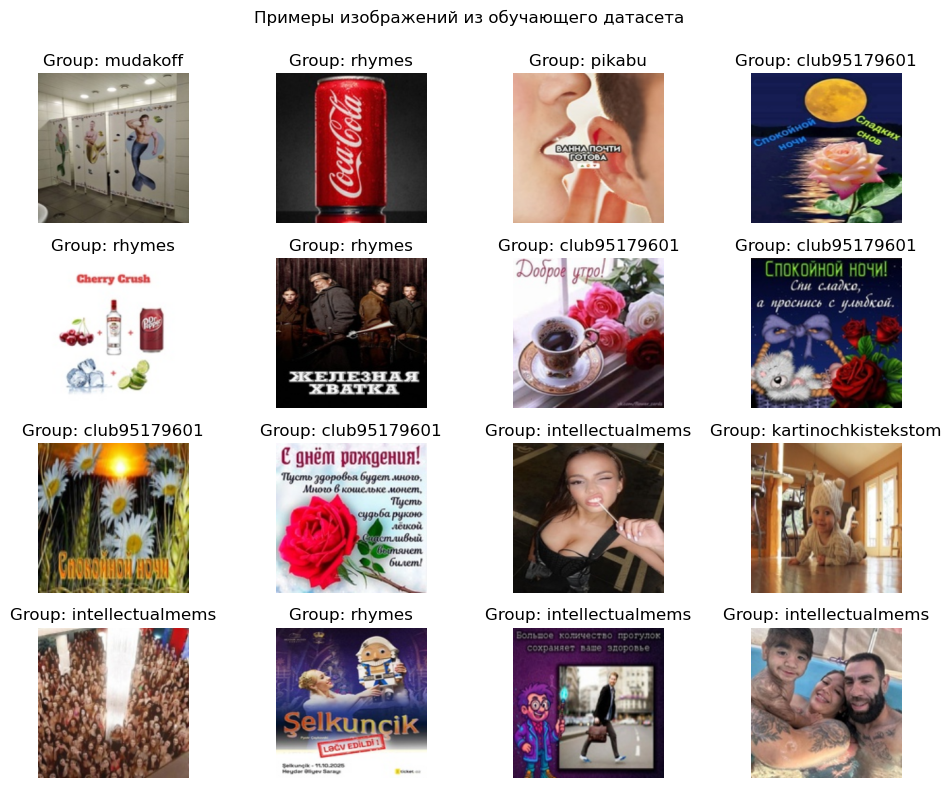

In [19]:
import matplotlib.pyplot as plt
plt.subplots(4, 4, figsize=(10, 8))
plt.suptitle("Примеры изображений из обучающего датасета")
j = 0
for i in np.random.randint(0, len(data), 16):
    plt.subplot(4, 4, j + 1)
    j += 1
    img = data[i][0]
    label = data[i][1].item()
    plt.imshow(img.permute(1, 2, 0).numpy())  # Преобразуем тензор в формат [H, W, C]
    plt.title(f"Group: {groups[label]}")
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()